<a href="https://colab.research.google.com/github/Clover130/u8229609-EMSC2010-W10-P1/blob/main/EMSC2010_W10_P1_NB4_u8229609.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W10-P1-NB4
Now it's your turn. Use the Fourier transform to analyse the LR04 oxygen isotope record spanning the 1.5-2.5 Ma time interval.

The data is in Excel file ```LR04_old.xlsx``` which is part of the GitHub repository. Remember to add/drag the file into your workspace so that it can be loaded into Colab.

In [1]:
import pandas as pd #for data import
import numpy as np #for numerical operations
import matplotlib.pyplot as plt #for plotting

In [2]:
def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal


def highpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff] = 0.0 #cycles below the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

def bandpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff[0]] = 0.0 #cycles below cutoff[0] are given an amplitude of 0
  fft_vals[freqs>cutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

In [4]:
file = 'LR04_old.xlsx' #datafile name
df = pd.read_excel(file) #read the data in as a dataframe
age = df['Age [ka]'].values #get the age values as a numpy array
d18O = df['d18O [per mil]'].values #get the d18O values as a numpy array
df.head()

,Age [ka],d18O [per mil]
0,1500.0,4.21
1,1502.5,4.29
2,1505.0,4.16
3,1507.5,4.15
4,1510.0,4.02


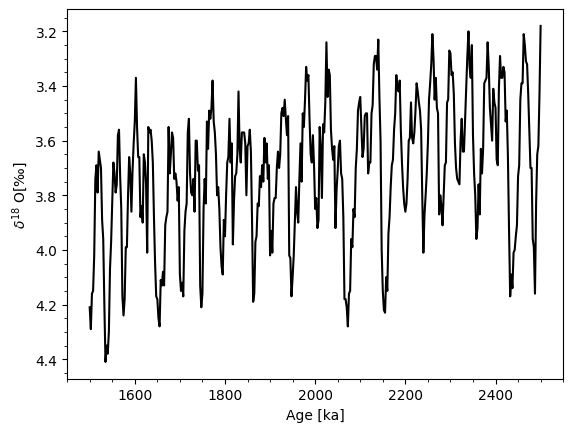

In [5]:
plt.plot(age,d18O,'k') #plot the d18O data
plt.xlabel('Age [ka]') #label the x-axis
plt.ylabel(r'$\delta^{18}$ O[$\perthousand$]') #label the y-axis
plt.gca().invert_yaxis() #invert the y-axis
#plt.xlim([0,800]) #limit the x-axis
plt.minorticks_on() #add minorticks

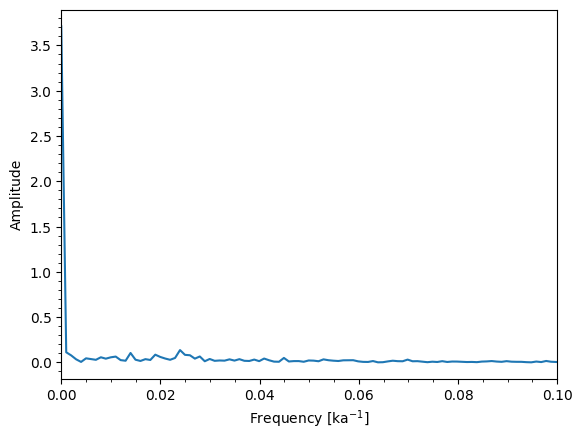

In [10]:
freqs, amps = freq_spectrum(age,d18O) #calculate the frequency spectrum
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [ka$^{-1}$]') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.xlim([0,0.1]) #limits the x-axis
plt.minorticks_on() #add minorticks

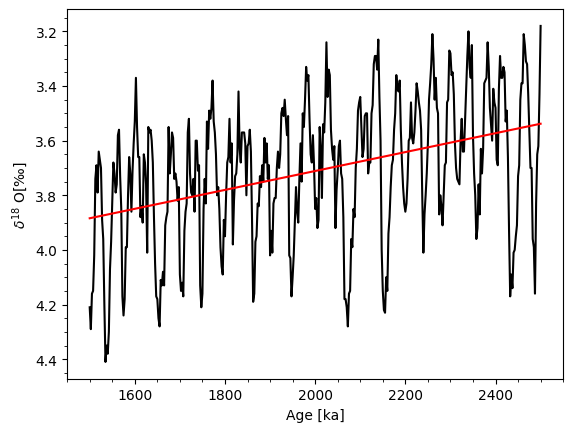

In [12]:
pp = np.polyfit(age,d18O,1) #fit a trendline to the data
plt.plot(age,d18O,'k') #plot the original data
plt.plot(age,np.polyval(pp,age),'r') #plot the trendline
plt.xlabel('Age [ka]') #label the x-axis
plt.ylabel(r'$\delta^{18}$ O[$\perthousand$]') #label the y-axis
plt.gca().invert_yaxis() #invert the y-axis
#plt.xlim([0,800]) #limit the x-axis
plt.minorticks_on() #add minorticks

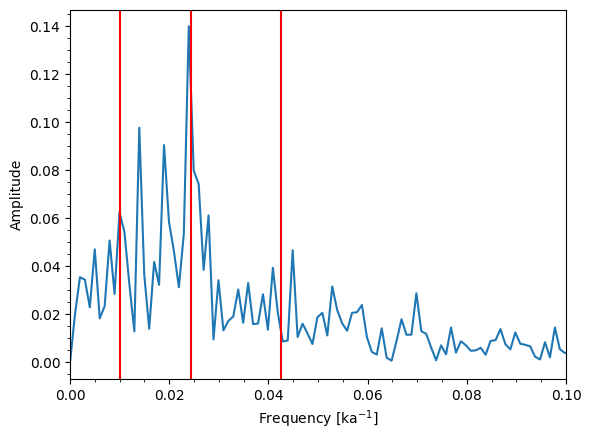

In [20]:
detrend = d18O-np.polyval(pp,age) #calculate the detrended data
freqs, amps = freq_spectrum(age,detrend) #frequency spectrum of the detrended data
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [ka$^{-1}$]') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.xlim([0,0.1]) #limits the x-axis
plt.minorticks_on() #add minorticks

plt.gca().axvline(x=1/100,color='r') #mark eccentricity frequency
plt.gca().axvline(x=1/41,color='r') #mark obliquity frequency
plt.gca().axvline(x=1/23.5,color='r') #mark precession frequency

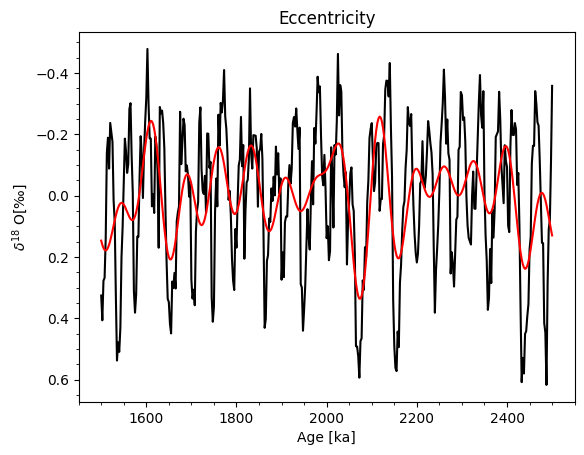

In [26]:
plt.plot(age,detrend,'k') #plot the detrended data
x, y = lowpass_filter(age,detrend,1/70) #obtain the filtered signal
plt.plot(x,y,'r') #plot the filtered signal
plt.xlabel('Age [ka]') #label the x-axis
plt.ylabel(r'$\delta^{18}$ O[$\perthousand$]') #label the y-axis
plt.gca().invert_yaxis() #invert the y-axis
plt.title('Eccentricity')
#plt.xlim([0,800]) #limit the x-axis
plt.minorticks_on() #add minorticks

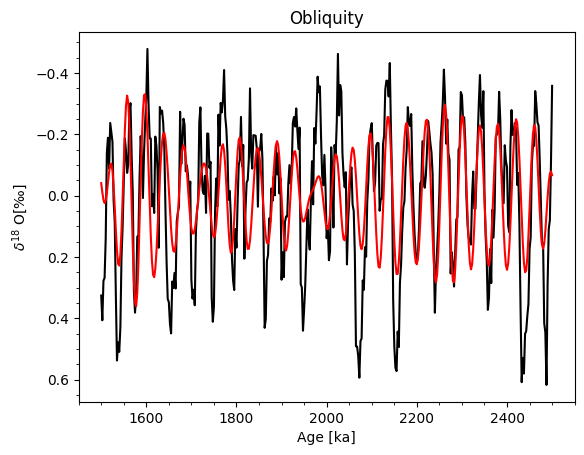

In [25]:
plt.plot(age,detrend,'k') #plot the detrended data
x, y = bandpass_filter(age,detrend,[1/50,1/30]) #obtain the filtered signal
plt.plot(x,y,'r') #plot the filtered signal
plt.xlabel('Age [ka]') #label the x-axis
plt.ylabel(r'$\delta^{18}$ O[$\perthousand$]') #label the y-axis
plt.gca().invert_yaxis() #invert the y-axis
#plt.xlim([0,800]) #limit the x-axis
plt.title('Obliquity')
plt.minorticks_on() #add minorticks

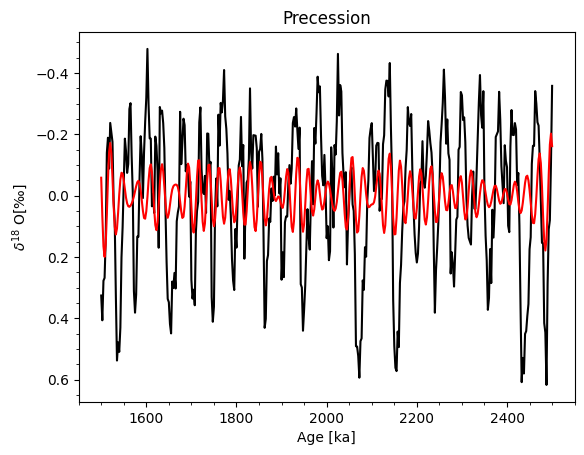

In [27]:
plt.plot(age,detrend,'k') #plot the detrended data
#x, y = highpass_filter(age,detrend,1/30) #obtain the filtered signal
x, y = bandpass_filter(age,detrend,[1/30,1/20]) #obtain the filtered signal
plt.plot(x,y,'r') #plot the filtered signal
plt.xlabel('Age [ka]') #label the x-axis
plt.ylabel(r'$\delta^{18}$ O[$\perthousand$]') #label the y-axis
plt.gca().invert_yaxis() #invert the y-axis
plt.title('Precession')
#plt.xlim([0,800]) #limit the x-axis
plt.minorticks_on() #add minorticks

## Interpretation
- eccentricity is dominant (period of 100) in 0-1 Ma
- something changes 1.5-1 Ma causing large scale ice ages driven by eccentricity
  - mid plistecene transition: papers trying to understand what caused that shift
- obliquity is dominant (smaller amplitude) in 1-3 Ma
- this shift would not be evident if using the entire plot
- assumption of fourier transform is that the signal runs for infinity in time without changing their properties (stationary signal)
- in climate we have a non stationary signal, the properties have changed through time
  - cut the non stationary signal into parts to determine if there are changes
  
- define frequencies by looking at how the signal changes, to do this we have to have a specific time interval
- if the window if infinitely small we won't be able to see any changes
- heisenburg's uncertianty principle